### Simple Linear Regression

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import norm,lognorm
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [6]:
btc_data = yf.download('BTC-USD',period='500d')
btc_data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [7]:
btc_data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-02-12,97885.859375,98151.023438,94101.203125,95745.695312,49340445530
2025-02-13,96623.867188,98111.085938,95269.710938,97888.750000,37147280860
2025-02-14,97508.968750,98819.468750,96342.804688,96623.367188,32697987277
2025-02-15,97580.351562,97975.039062,97240.195312,97508.382812,17047266288
2025-02-16,96175.031250,97725.593750,96060.976562,97580.492188,16536755396
...,...,...,...,...,...
2026-06-22,63952.105469,65544.000000,63233.531250,63240.789062,26561496819
2026-06-23,62668.019531,64196.562500,61893.207031,63952.792969,29608942370


In [15]:
btc_data['Day Index'] = np.arange(len(btc_data))
btc_data['Day Index']
X = btc_data['Day Index']
y = btc_data['Close']

In [23]:
X.shape

(500,)

In [22]:
y.shape

(500, 1)

In [24]:
X = X.to_frame()

y = y.squeeze()


In [25]:
X.shape

(500, 1)

In [26]:
y.shape

(500,)

In [27]:
# Training of ML model 
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-69.95]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Day Index']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.096e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
# Model existing data ko kitna achha fit kar raha hai
btc_data['Predicted_Close'] = model.predict(X)
btc_data['Predicted_Close']

Date
2025-02-12    109637.007033
2025-02-13    109567.054511
2025-02-14    109497.101990
2025-02-15    109427.149468
2025-02-16    109357.196946
                  ...      
2026-06-22     75010.508835
2026-06-23     74940.556313
2026-06-24     74870.603792
2026-06-25     74800.651270
2026-06-26     74730.698748
Name: Predicted_Close, Length: 500, dtype: float64

What is Residual?
Actual Point     ●

Prediction Line ----------------

Residual = point aur line ke beech distance

Linear Regression actually internally ye hi karta hai:

Residuals se pata chal sakta hai:

1. Model kitna galat ho raha hai
2. Overfitting hai ya nahi
3. Outliers hain ya nahi
4. Prediction quality

Interesting quant use case:

Residual bahut positive
→ price expected se zyada upar

Residual bahut negative
→ price expected se zyada neeche

Residual = Model kitna galat tha

In [31]:
type(btc_data['Close'])

pandas.DataFrame

In [32]:
btc_data['Residual'] = (
    btc_data['Close'].squeeze() -
    btc_data['Predicted_Close']
)

In [36]:
btc_data['Residual']

Date
2025-02-12   -11751.147658
2025-02-13   -12943.187324
2025-02-14   -11988.133240
2025-02-15   -11846.797906
2025-02-16   -13182.165696
                  ...     
2026-06-22   -11058.403366
2026-06-23   -12272.536782
2026-06-24   -13875.470979
2026-06-25   -15078.975489
2026-06-26   -15357.237811
Name: Residual, Length: 500, dtype: float64

In [34]:
btc_data['Close'].squeeze()

Date
2025-02-12    97885.859375
2025-02-13    96623.867188
2025-02-14    97508.968750
2025-02-15    97580.351562
2025-02-16    96175.031250
                  ...     
2026-06-22    63952.105469
2026-06-23    62668.019531
2026-06-24    60995.132812
2026-06-25    59721.675781
2026-06-26    59373.460938
Name: BTC-USD, Length: 500, dtype: float64

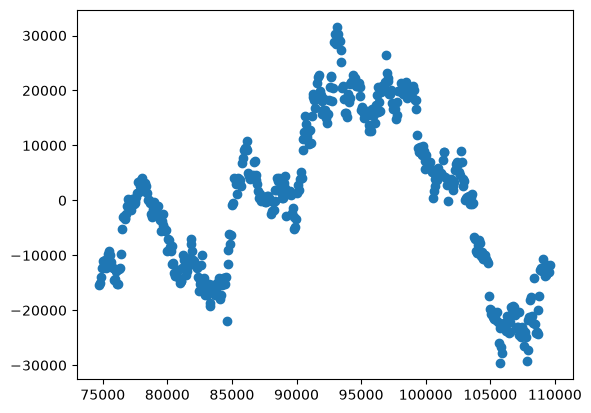

In [35]:
plt.scatter(
    btc_data['Predicted_Close'],
    btc_data['Residual']
)

In [39]:
# Calculate the std of the residuals
std_dev = np.std(btc_data['Residual'])
std_dev

np.float64(14151.069269972772)

In [40]:
# Cal the lower bands and uppar bands (2 standard deviations)
# Prediction ke upar aur niche ek safe range bana rahe ho

# Predicted Close = 100000

# Std Dev = 5000

# Upper Band
# =100000 + (2×5000)
# =110000

# Lower Band
# =100000 − (2×5000)
# =90000

# Lower      Prediction      Upper
# 90000 ------100000------110000
btc_data['Upper_Band'] = btc_data['Predicted_Close'] + 2 * std_dev
btc_data['Lower_Band'] = btc_data['Predicted_Close'] - 2 * std_dev

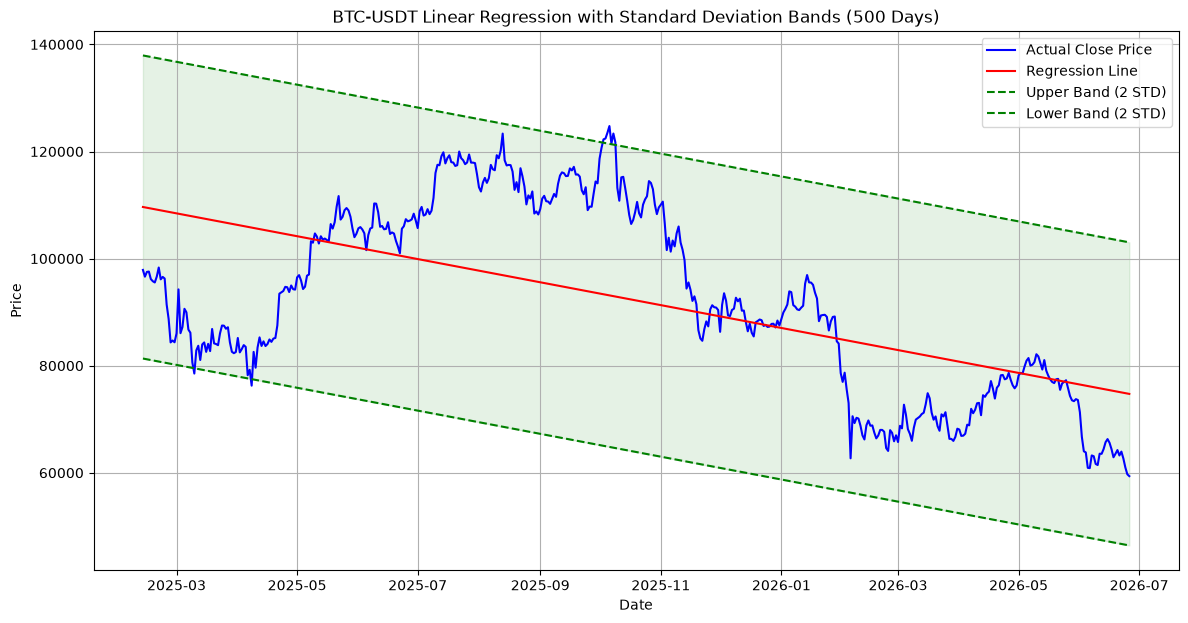

In [41]:
# Step 9: Plot the closing price, regression line, and standard deviation bands
plt.figure(figsize=(14, 7))
plt.plot(btc_data.index, btc_data['Close'], label='Actual Close Price', color='blue')
plt.plot(btc_data.index, btc_data['Predicted_Close'], label='Regression Line', color='red')
plt.plot(btc_data.index, btc_data['Upper_Band'], label='Upper Band (2 STD)', linestyle='--', color='green')
plt.plot(btc_data.index, btc_data['Lower_Band'], label='Lower Band (2 STD)', linestyle='--', color='green')
plt.fill_between(btc_data.index, btc_data['Upper_Band'], btc_data['Lower_Band'], color='green', alpha=0.1)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC-USDT Linear Regression with Standard Deviation Bands (500 Days)')
plt.legend()
plt.grid(True)
plt.show()